## Amazon Price Trend Analysis : Stackline US Mattress

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [3]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../market-analysis-project-91130-5213911f50a5.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [4]:
# get the Matttress data from BigQuery
sql = f"""
select * from wook.stckln_amz_mattress_ms_trend 
"""

df_mattress = bqclient.query(sql).to_dataframe()

In [9]:
print(df_mattress)

        RetailerSku         category    subcategory profile      size_raw  \
0        B0D4Z5H8G3           OTHERS         OTHERS    None          None   
1        B003HEA8RG           OTHERS         OTHERS    None          None   
2        B07SJJMHJD           OTHERS         OTHERS    None          None   
3        B07ZRB1WRK           OTHERS         OTHERS    None          None   
4        B09YDBV81F           OTHERS         OTHERS    None          None   
...             ...              ...            ...     ...           ...   
1219415  B081XTMDMV  Spring Mattress  Pocket Spring      14       Twin XL   
1219416  B0B8SM3G5P  Spring Mattress  Pocket Spring      12       Twin XL   
1219417  B09HX2T8BS    Foam Mattress    Non-Cooling      10       Twin-XL   
1219418  B06XSGYGLV    Foam Mattress    Cooling/Gel       8  X-Large Twin   
1219419  B0DJVRNGKC  Spring Mattress  Pocket Spring      10      cal_king   

            size bsr_ctgry_label bw_ff_type               brand  \
0       

In [11]:
cates = ['Foam Mattress','Spring Mattress']
subcates = ['Cooling/Gel','Non-Cooling','Pocket Spring','Bonnell']

df1 = df_mattress[
    df_mattress['category'].isin(cates) & 
    df_mattress['subcategory'].isin(subcates) 
]

In [13]:
print(df1)

        RetailerSku         category    subcategory profile      size_raw  \
28       B09NC4986G    Foam Mattress    Non-Cooling       5          None   
29       B09NC4986G    Foam Mattress    Non-Cooling       5          None   
47       B00FT69TF2    Foam Mattress    Cooling/Gel       5          None   
49       B08TR6LWYD  Spring Mattress  Pocket Spring  OTHERS          None   
50       B08TR58WFC  Spring Mattress  Pocket Spring      13          None   
...             ...              ...            ...     ...           ...   
1219415  B081XTMDMV  Spring Mattress  Pocket Spring      14       Twin XL   
1219416  B0B8SM3G5P  Spring Mattress  Pocket Spring      12       Twin XL   
1219417  B09HX2T8BS    Foam Mattress    Non-Cooling      10       Twin-XL   
1219418  B06XSGYGLV    Foam Mattress    Cooling/Gel       8  X-Large Twin   
1219419  B0DJVRNGKC  Spring Mattress  Pocket Spring      10      cal_king   

            size bsr_ctgry_label bw_ff_type                       brand  \


In [17]:
# 1) 단순 평균 (RetailPrice가 0인 행 제외)
avg_price = (
    df1[df1['RetailPrice'] > 0]
      .groupby(['category', 'yr_quarter'], as_index=False)['RetailPrice']
      .mean()
      .rename(columns={'RetailPrice': 'avg_price'})
      .sort_values(['category', 'yr_quarter'])
)
print(avg_price)

           category yr_quarter   avg_price
0     Foam Mattress       19-1  380.637926
1     Foam Mattress       19-2  361.015885
2     Foam Mattress       19-3  352.338625
3     Foam Mattress       19-4  345.741219
4     Foam Mattress       20-1  325.166316
5     Foam Mattress       20-2  337.596745
6     Foam Mattress       20-3  360.443766
7     Foam Mattress       20-4  357.180856
8     Foam Mattress       21-1  356.306083
9     Foam Mattress       21-2  384.762597
10    Foam Mattress       21-3  390.517689
11    Foam Mattress       21-4  389.611281
12    Foam Mattress       22-1  394.375919
13    Foam Mattress       22-2  380.036882
14    Foam Mattress       22-3  366.347486
15    Foam Mattress       22-4  347.544560
16    Foam Mattress       23-1  341.797247
17    Foam Mattress       23-2  329.642235
18    Foam Mattress       23-3  313.552795
19    Foam Mattress       23-4  302.134584
20    Foam Mattress       24-1  293.622702
21    Foam Mattress       24-2  286.758739
22    Foam 

In [23]:
# 2) 가중평균: 총매출 / 총판매수량
weighted = (
    df1.groupby(['category', 'yr_quarter'])
      .apply(lambda g: g['RetailSales'].sum() / g['UnitsSold'].sum()
             if g['UnitsSold'].sum() > 0 else None,
            include_groups=False)
      .reset_index(name='weighted_avg_price')
      .sort_values(['category', 'yr_quarter'])
)
print(weighted)

           category yr_quarter  weighted_avg_price
0     Foam Mattress       19-1          236.497287
1     Foam Mattress       19-2          238.213989
2     Foam Mattress       19-3          250.452301
3     Foam Mattress       19-4          236.673430
4     Foam Mattress       20-1          222.991404
5     Foam Mattress       20-2          227.455607
6     Foam Mattress       20-3          247.621219
7     Foam Mattress       20-4          255.008093
8     Foam Mattress       21-1          260.248850
9     Foam Mattress       21-2          277.428701
10    Foam Mattress       21-3          288.055509
11    Foam Mattress       21-4          309.502054
12    Foam Mattress       22-1          299.244553
13    Foam Mattress       22-2          284.178259
14    Foam Mattress       22-3          266.923691
15    Foam Mattress       22-4          248.600974
16    Foam Mattress       23-1          244.810110
17    Foam Mattress       23-2          228.334576
18    Foam Mattress       23-3 

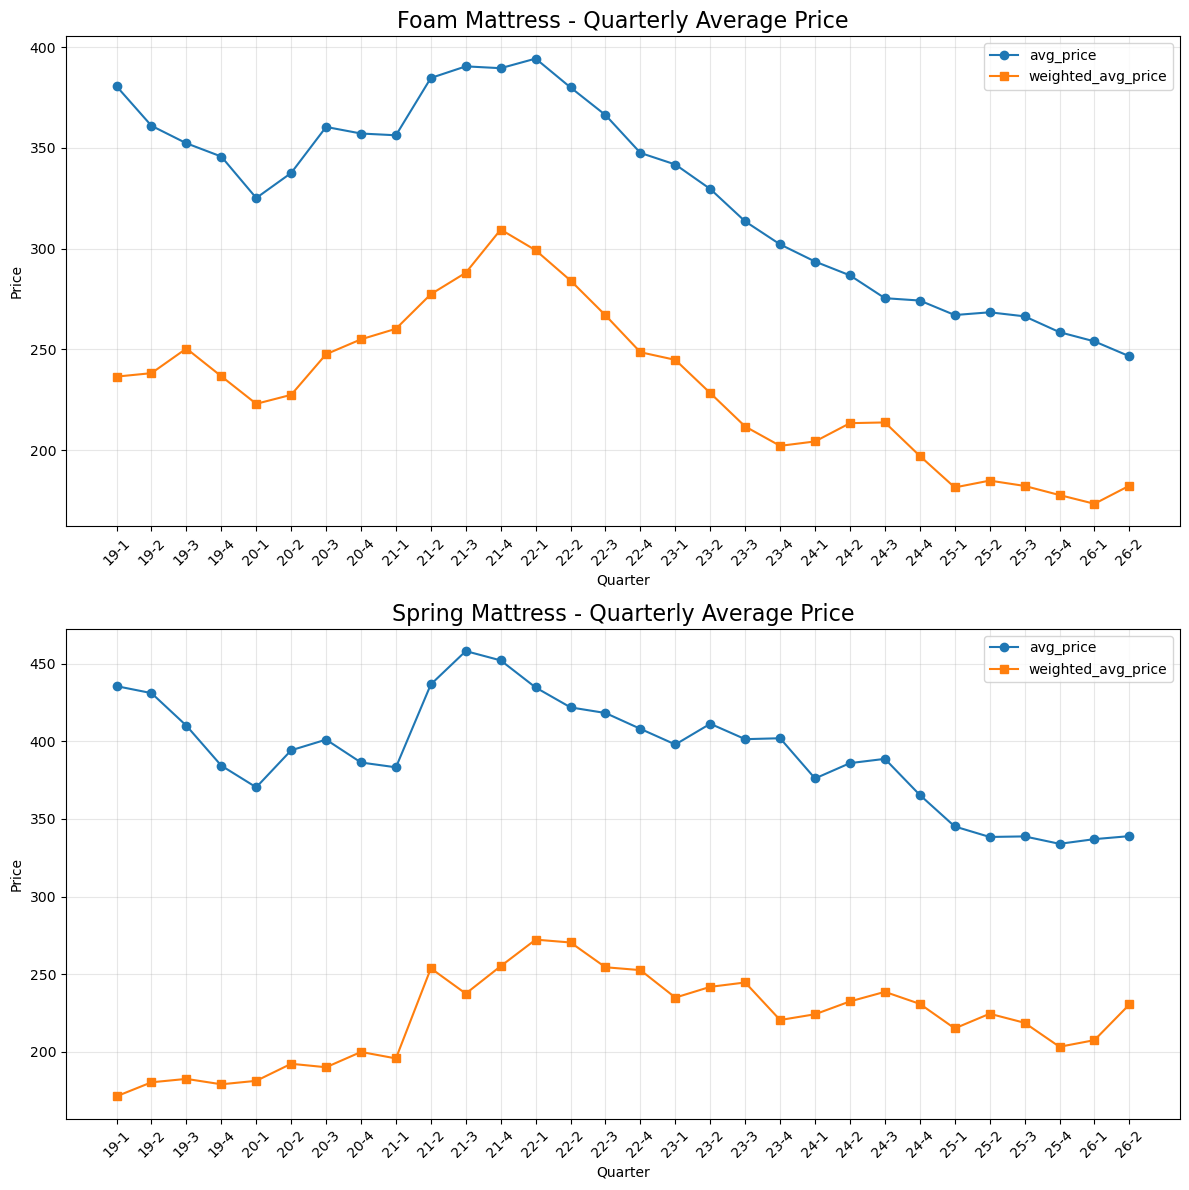

In [37]:
# 1) 단순 평균
avg_price = (
    df1[df1['RetailPrice'] > 0]
      .groupby(['category', 'yr_quarter'], as_index=False)['RetailPrice']
      .mean()
      .rename(columns={'RetailPrice': 'avg_price'})
)

# 2) 가중 평균
g = df1.groupby(['category', 'yr_quarter'])[['RetailSales', 'UnitsSold']].sum()
weighted = (
    (g['RetailSales'] / g['UnitsSold'].where(g['UnitsSold'] > 0))
    .reset_index(name='weighted_avg_price')
)

# 3) 두 결과 병합
merged = avg_price.merge(weighted, on=['category', 'yr_quarter'])
merged = merged.sort_values(['category', 'yr_quarter'])

# 4) category별 subplot
categories = merged['category'].unique()
n = len(categories)

fig, axes = plt.subplots(n, 1, figsize=(12, 6 * n), sharex=False)
if n == 1:
    axes = [axes]

for ax, cat in zip(axes, categories):
    sub = merged[merged['category'] == cat]
    ax.plot(sub['yr_quarter'], sub['avg_price'],
            marker='o', label='avg_price')
    ax.plot(sub['yr_quarter'], sub['weighted_avg_price'],
            marker='s', label='weighted_avg_price')
    ax.set_title(f'{cat} - Quarterly Average Price', fontsize=16)
    ax.set_xlabel('Quarter')
    ax.set_ylabel('Price')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

   yr_quarter   avg_price  weighted_avg_price
0        19-1  399.508264          211.217517
1        19-2  384.790375          218.547097
2        19-3  372.724842          224.545793
3        19-4  359.363306          213.718227
4        20-1  341.103482          207.064067
5        20-2  357.057574          213.350012
6        20-3  375.600898          223.491648
7        20-4  368.069357          233.718186
8        21-1  366.544055          233.060359
9        21-2  403.849262          270.019808
10       21-3  415.529726          270.709981
11       21-4  412.829656          289.212607
12       22-1  410.322996          289.478226
13       22-2  396.607784          279.137848
14       22-3  387.600056           262.63707
15       22-4  372.323088          249.957395
16       23-1  365.216009          241.202737
17       23-2  364.244344          233.100063
18       23-3  351.272275          223.742757
19       23-4  346.592628          209.649071
20       24-1  330.801695         

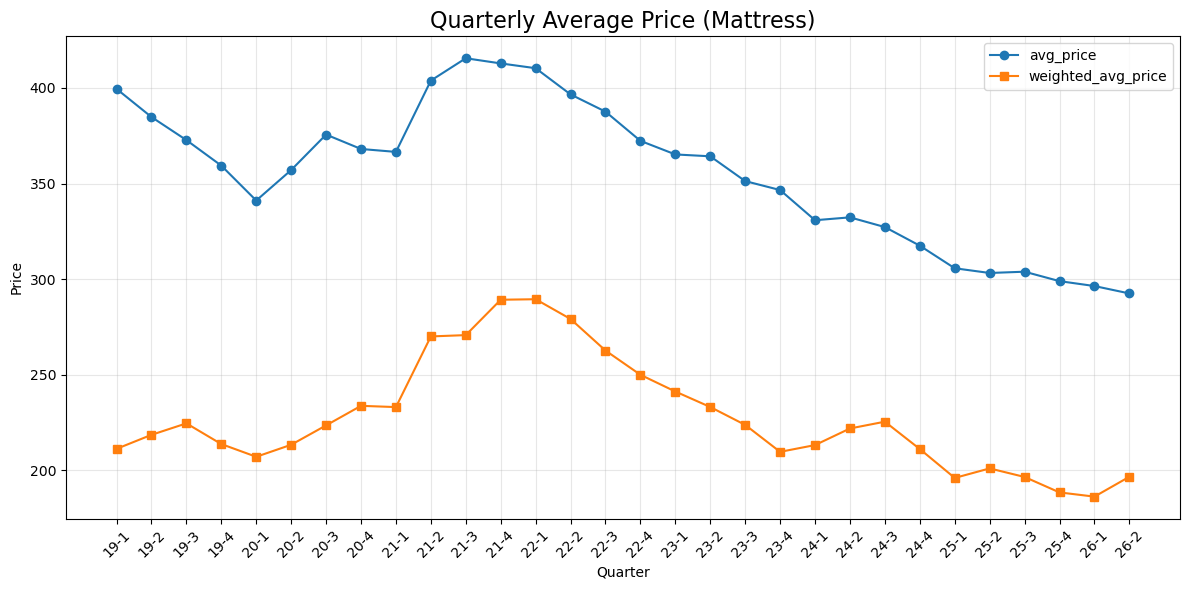

In [43]:

# 1) 단순 평균 (분기별, 카테고리 구분 없음)
avg_price = (
    df1[df1['RetailPrice'] > 0]
      .groupby('yr_quarter', as_index=False)['RetailPrice']
      .mean()
      .rename(columns={'RetailPrice': 'avg_price'})
)

# 2) 가중 평균 (분기별)
g = df1.groupby('yr_quarter')[['RetailSales', 'UnitsSold']].sum()
weighted = (
    (g['RetailSales'] / g['UnitsSold'].where(g['UnitsSold'] > 0))
    .reset_index(name='weighted_avg_price')
)

# 3) 병합 및 정렬
merged = avg_price.merge(weighted, on='yr_quarter').sort_values('yr_quarter')
print(merged)

# 4) 단일 그래프
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(merged['yr_quarter'], merged['avg_price'],
        marker='o', label='avg_price')
ax.plot(merged['yr_quarter'], merged['weighted_avg_price'],
        marker='s', label='weighted_avg_price')

ax.set_title('Quarterly Average Price (Mattress)', fontsize=16)
ax.set_xlabel('Quarter')
ax.set_ylabel('Price')
ax.legend()
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('quarterly_price.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
plt